# Current Global Scoring

This notebook applies the existing Global Fragility Index framework to present-day global conditions through a manual, uncertainty-aware scoring workflow.

It is **not** a prediction of collapse and **not** a probability model. The goal is to measure overlap with historically recurrent fragility patterns found in the historical dataset, while keeping evidence standards and limitations explicit.

In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.style.use("default")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

## Scoring Guidance

- Scores should be assigned manually from current evidence, not auto-generated from headlines.
- Use the same 0 to 3 scale across all factors:
  - `0` = absent / negligible
  - `1` = low
  - `2` = moderate
  - `3` = high
- Keep the historical weights fixed. The point is to compare present-day conditions against the historical pattern structure already derived in this project.
- For each factor, add a short evidence note and confidence judgment so the score remains auditable.

## Evidence Standard

- Use current public indicators, reputable reporting, or institutional datasets when you fill the template.
- Prefer multiple sources or converging indicators for higher scores.
- If the evidence is mixed or ambiguous, use a lower confidence label and avoid overstating the score.
- This notebook does not fetch live data automatically; it is designed for manual, documented scoring.

## Load Templates And Historical Weights

The historical factor structure and weights are always loaded from `global_fragility_manual_template.csv`. If `global_fragility_current_scoring_template.csv` contains user-entered scores or notes, those fields are layered on top without changing the weights.

In [10]:
project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

manual_template_path = project_root / "data" / "processed" / "global_fragility_manual_template.csv"
current_template_path = project_root / "data" / "processed" / "global_fragility_current_scoring_template.csv"

manual_template = pd.read_csv(manual_template_path)
current_template = pd.read_csv(current_template_path) if current_template_path.exists() else pd.DataFrame()

base_columns = ["factor_name", "historical_category", "historical_weight"]
current_columns = ["factor_name", "current_global_score_0_to_3", "confidence_level", "evidence_notes", "weighted_score"]

working_df = manual_template[base_columns].copy()

if not current_template.empty:
    mergeable = current_template[[col for col in current_columns if col in current_template.columns]]
    working_df = working_df.merge(mergeable, on="factor_name", how="left")
else:
    working_df["current_global_score_0_to_3"] = pd.NA
    working_df["confidence_level"] = ""
    working_df["evidence_notes"] = ""
    working_df["weighted_score"] = pd.NA

role_map = {factor_name: "stress" for factor_name in working_df["factor_name"]}
role_map["adaptive_capacity_resilience"] = "resilience"
working_df["role"] = working_df["factor_name"].map(role_map)

display(working_df)

,factor_name,historical_category,historical_weight,current_global_score_0_to_3,confidence_level,evidence_notes,weighted_score,role
0,legitimacy_crisis,political,0.106313,2,medium,Global democratic legitimacy is under broad st...,NaN,stress
1,geopolitical_instability,military_geopolitical,0.100526,3,high,Russia-Ukraine war and wider Middle East insta...,NaN,stress
2,adaptive_capacity_resilience,resilience_institutional,0.098742,2,medium,The global system still has meaningful resilie...,NaN,resilience
3,political_fragmentation_polarization,political,0.096189,2,medium,Growing bloc polarization and widespread polit...,NaN,stress
4,trade_disruption,economic,0.094495,3,high,Energy and shipping disruptions are pushing up...,NaN,stress
5,conflict_pressure,military_geopolitical,0.089513,3,high,Multiple active wars with cross-border spillov...,NaN,stress
6,fiscal_strain,economic,0.082360,1,low,The global economy remains relatively resilien...,NaN,stress
7,urban_social_stress,social,0.079924,2,medium,High forced displacement and persistent social...,NaN,stress
8,institutional_rigidity,political+resilience_institutional,0.079556,2,medium,"Institutions are responding, but slow adaptati...",NaN,stress
9,food_insecurity,economic+environmental,0.075357,2,high,Large-scale hunger and acute food insecurity r...,NaN,stress


## Optional Manual Updates Inside The Notebook

You can either edit `global_fragility_current_scoring_template.csv` directly and rerun the notebook, or paste updates into the dictionary below.

Leave it blank until you are ready to score.

In [11]:
manual_updates = {
    # "legitimacy_crisis": {
    #     "current_global_score_0_to_3": 2,
    #     "confidence_level": "medium",
    #     "evidence_notes": "Paste short justification here.",
    # },
}

for factor_name, updates in manual_updates.items():
    row_mask = working_df["factor_name"].eq(factor_name)
    if not row_mask.any():
        raise KeyError(f"Unknown factor_name: {factor_name}")
    for key, value in updates.items():
        if key in working_df.columns:
            working_df.loc[row_mask, key] = value

display(working_df)

,factor_name,historical_category,historical_weight,current_global_score_0_to_3,confidence_level,evidence_notes,weighted_score,role
0,legitimacy_crisis,political,0.106313,2,medium,Global democratic legitimacy is under broad st...,NaN,stress
1,geopolitical_instability,military_geopolitical,0.100526,3,high,Russia-Ukraine war and wider Middle East insta...,NaN,stress
2,adaptive_capacity_resilience,resilience_institutional,0.098742,2,medium,The global system still has meaningful resilie...,NaN,resilience
3,political_fragmentation_polarization,political,0.096189,2,medium,Growing bloc polarization and widespread polit...,NaN,stress
4,trade_disruption,economic,0.094495,3,high,Energy and shipping disruptions are pushing up...,NaN,stress
5,conflict_pressure,military_geopolitical,0.089513,3,high,Multiple active wars with cross-border spillov...,NaN,stress
6,fiscal_strain,economic,0.082360,1,low,The global economy remains relatively resilien...,NaN,stress
7,urban_social_stress,social,0.079924,2,medium,High forced displacement and persistent social...,NaN,stress
8,institutional_rigidity,political+resilience_institutional,0.079556,2,medium,"Institutions are responding, but slow adaptati...",NaN,stress
9,food_insecurity,economic+environmental,0.075357,2,high,Large-scale hunger and acute food insecurity r...,NaN,stress


## Compute Weighted Scores

Weighted scores are calculated automatically from the manual scores you enter. Resilience is handled separately in the summary metrics so that stronger resilience offsets fragility rather than inflating it.

In [12]:
score_numeric = pd.to_numeric(working_df["current_global_score_0_to_3"], errors="coerce")
invalid_mask = score_numeric.notna() & ~score_numeric.isin([0, 1, 2, 3])
if invalid_mask.any():
    invalid_rows = working_df.loc[invalid_mask, ["factor_name", "current_global_score_0_to_3"]]
    raise ValueError(f"Scores must be 0, 1, 2, or 3. Invalid rows:\n{invalid_rows}")

working_df["score_numeric"] = score_numeric
working_df["weighted_score"] = working_df["historical_weight"] * (working_df["score_numeric"] / 3)
working_df["net_fragility_contribution"] = working_df["weighted_score"]

resilience_mask = working_df["role"].eq("resilience") & working_df["score_numeric"].notna()
working_df.loc[resilience_mask, "net_fragility_contribution"] = (
    working_df.loc[resilience_mask, "historical_weight"] * (1 - (working_df.loc[resilience_mask, "score_numeric"] / 3))
)

display(working_df[[
    "factor_name",
    "historical_category",
    "historical_weight",
    "current_global_score_0_to_3",
    "confidence_level",
    "evidence_notes",
    "weighted_score",
]])

,factor_name,historical_category,historical_weight,current_global_score_0_to_3,confidence_level,evidence_notes,weighted_score
0,legitimacy_crisis,political,0.106313,2,medium,Global democratic legitimacy is under broad st...,0.070875
1,geopolitical_instability,military_geopolitical,0.100526,3,high,Russia-Ukraine war and wider Middle East insta...,0.100526
2,adaptive_capacity_resilience,resilience_institutional,0.098742,2,medium,The global system still has meaningful resilie...,0.065828
3,political_fragmentation_polarization,political,0.096189,2,medium,Growing bloc polarization and widespread polit...,0.064126
4,trade_disruption,economic,0.094495,3,high,Energy and shipping disruptions are pushing up...,0.094495
5,conflict_pressure,military_geopolitical,0.089513,3,high,Multiple active wars with cross-border spillov...,0.089513
6,fiscal_strain,economic,0.082360,1,low,The global economy remains relatively resilien...,0.027453
7,urban_social_stress,social,0.079924,2,medium,High forced displacement and persistent social...,0.053283
8,institutional_rigidity,political+resilience_institutional,0.079556,2,medium,"Institutions are responding, but slow adaptati...",0.053037
9,food_insecurity,economic+environmental,0.075357,2,high,Large-scale hunger and acute food insecurity r...,0.050238


## Summary Metrics

In [13]:
entered_mask = working_df["score_numeric"].notna()
entered_weight_total = working_df.loc[entered_mask, "historical_weight"].sum()

stress_mask = working_df["role"].eq("stress")
stress_entered = stress_mask & entered_mask
resilience_entered = resilience_mask

stress_weight_total = working_df.loc[stress_mask, "historical_weight"].sum()
resilience_weight_total = working_df.loc[working_df["role"].eq("resilience"), "historical_weight"].sum()

total_weighted_stress_score = (
    100 * working_df.loc[stress_entered, "weighted_score"].sum() / stress_weight_total
    if stress_entered.any() else pd.NA
)
total_weighted_resilience_score = (
    100 * working_df.loc[resilience_entered, "weighted_score"].sum() / resilience_weight_total
    if resilience_entered.any() else pd.NA
)
net_global_fragility_score = (
    100 * working_df.loc[entered_mask, "net_fragility_contribution"].sum() / entered_weight_total
    if entered_mask.any() else pd.NA
)
normalized_0_to_100_index = net_global_fragility_score

def interpret_band(value):
    if pd.isna(value):
        return "No score yet"
    if value <= 20:
        return "Low overlap"
    if value <= 40:
        return "Mild fragility"
    if value <= 60:
        return "Moderate fragility"
    if value <= 80:
        return "High fragility"
    return "Severe systemic stress"

summary_table = pd.DataFrame(
    {
        "metric": [
            "entered_factor_count",
            "entered_weight_coverage",
            "total_weighted_stress_score",
            "total_weighted_resilience_score",
            "net_global_fragility_score",
            "normalized_0_to_100_index",
            "interpretation_band",
        ],
        "value": [
            int(entered_mask.sum()),
            round(float(entered_weight_total), 3),
            None if pd.isna(total_weighted_stress_score) else round(float(total_weighted_stress_score), 2),
            None if pd.isna(total_weighted_resilience_score) else round(float(total_weighted_resilience_score), 2),
            None if pd.isna(net_global_fragility_score) else round(float(net_global_fragility_score), 2),
            None if pd.isna(normalized_0_to_100_index) else round(float(normalized_0_to_100_index), 2),
            interpret_band(normalized_0_to_100_index),
        ],
    }
)

display(summary_table)

if not entered_mask.all():
    remaining = int((~entered_mask).sum())
    display(Markdown(f"**Scoring status**: `{remaining}` factors still have no present-day score. Summary metrics are provisional until all factors are scored."))

,metric,value
0,entered_factor_count,12
1,entered_weight_coverage,1.0
2,total_weighted_stress_score,77.73
3,total_weighted_resilience_score,66.67
4,net_global_fragility_score,73.35
5,normalized_0_to_100_index,73.35
6,interpretation_band,High fragility


## Interpretation Bands

In [14]:
interpretation_bands = pd.DataFrame(
    {
        "score_range": ["0-20", "21-40", "41-60", "61-80", "81-100"],
        "meaning": [
            "Low overlap",
            "Mild fragility",
            "Moderate fragility",
            "High fragility",
            "Severe systemic stress",
        ],
        "interpretation_note": [
            "Low overlap with historically recurrent collapse-stress patterns",
            "Limited but visible overlap with historical fragility patterns",
            "Meaningful overlap with multiple historical stress patterns",
            "Strong overlap with historically recurrent systemic stress patterns",
            "Very strong overlap with historical fragility patterns, not collapse probability",
        ],
    }
)

display(interpretation_bands)

,score_range,meaning,interpretation_note
0,0-20,Low overlap,Low overlap with historically recurrent collap...
1,21-40,Mild fragility,Limited but visible overlap with historical fr...
2,41-60,Moderate fragility,Meaningful overlap with multiple historical st...
3,61-80,High fragility,Strong overlap with historically recurrent sys...
4,81-100,Severe systemic stress,Very strong overlap with historical fragility ...


## Compact Final Table

In [15]:
compact_table = working_df[[
    "factor_name",
    "current_global_score_0_to_3",
    "historical_weight",
    "weighted_score",
    "confidence_level",
]].rename(columns={
    "factor_name": "factor",
    "current_global_score_0_to_3": "score",
    "historical_weight": "weight",
    "weighted_score": "weighted_contribution",
    "confidence_level": "confidence",
})

display(compact_table)

,factor,score,weight,weighted_contribution,confidence
0,legitimacy_crisis,2,0.106313,0.070875,medium
1,geopolitical_instability,3,0.100526,0.100526,high
2,adaptive_capacity_resilience,2,0.098742,0.065828,medium
3,political_fragmentation_polarization,2,0.096189,0.064126,medium
4,trade_disruption,3,0.094495,0.094495,high
5,conflict_pressure,3,0.089513,0.089513,high
6,fiscal_strain,1,0.082360,0.027453,low
7,urban_social_stress,2,0.079924,0.053283,medium
8,institutional_rigidity,2,0.079556,0.053037,medium
9,food_insecurity,2,0.075357,0.050238,high


## Weighted Contribution Chart

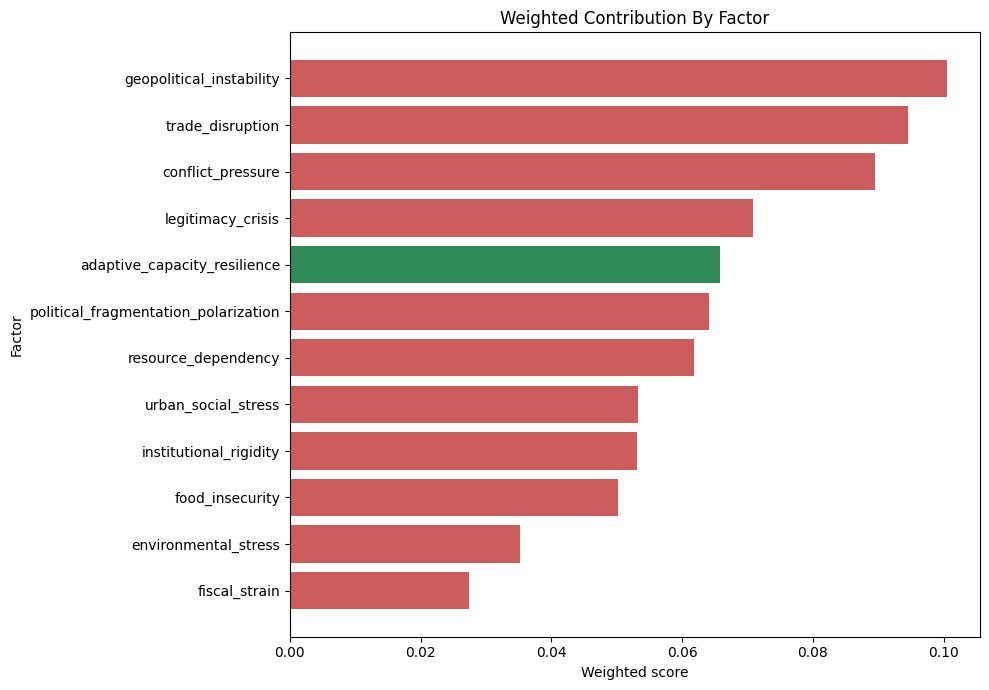

In [16]:
chart_df = working_df.loc[entered_mask, ["factor_name", "weighted_score", "role"]].copy()

if chart_df.empty:
    display(Markdown("No present-day scores entered yet, so there is no weighted contribution chart to display."))
else:
    colors = chart_df["role"].map({"stress": "indianred", "resilience": "seagreen"})
    chart_df = chart_df.sort_values("weighted_score")
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(chart_df["factor_name"], chart_df["weighted_score"], color=colors.loc[chart_df.index])
    ax.set_title("Weighted Contribution By Factor")
    ax.set_xlabel("Weighted score")
    ax.set_ylabel("Factor")
    plt.tight_layout()
    plt.show()

## Limits of Interpretation

- This index measures overlap with historically recurrent fragility patterns, not collapse probability.
- The historical weights are fixed from the existing project analysis and should not be treated as timeless universal constants.
- Present-day scoring is only as good as the evidence notes and confidence judgments you enter.
- A high score should be read as stronger pattern overlap with historical fragility dynamics, not as a deterministic forecast.
- A low score should not be read as proof of safety; it only indicates lower overlap within this particular historical framework.